# 🏠 House Price Prediction
## Task 2: Feature Engineering & Model Optimization

### Objective
The objective of this project is to improve the House Price Prediction model by applying Feature Engineering techniques and comparing multiple regression algorithms to identify the best-performing model.

### Dataset
California Housing Dataset (Scikit-learn)

### Algorithms Used
- Linear Regression
- Ridge Regression
- Decision Tree Regressor

### Evaluation Metrics
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

# 📚 Step 1: Import Required Libraries

In this step, all the required Python libraries are imported. These libraries are used for data handling, visualization, preprocessing, model training, and evaluation.

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# 📂 Step 2: Load the Dataset

The California Housing Dataset is loaded from Scikit-learn and converted into a Pandas DataFrame for further analysis.

In [2]:
# Load the dataset
housing = fetch_california_housing()

# Convert it into a DataFrame
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Add the target column
df["HousePrice"] = housing.target

print("✅ Dataset loaded successfully!")

# Display the first 5 rows
df.head()

✅ Dataset loaded successfully!


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# 🔍 Step 3: Exploratory Data Analysis (EDA)

EDA is performed to understand the dataset by checking:
- Dataset shape
- Data types
- Missing values
- Statistical summary
- Sample records

In [3]:
# Dataset Shape
print("Dataset Shape:")
print(df.shape)

# Column Names
print("\nColumn Names:")
print(df.columns)

# Data Types
print("\nData Types:")
print(df.dtypes)

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical Summary
print("\nStatistical Summary:")
display(df.describe())

# First 5 Rows
print("\nFirst 5 Rows:")
display(df.head())

# Last 5 Rows
print("\nLast 5 Rows:")
display(df.tail())

Dataset Shape:
(20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'HousePrice'],
      dtype='object')

Data Types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
HousePrice    float64
dtype: object

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



First 5 Rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Last 5 Rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


# ⚙️ Step 4: Feature Scaling

Feature Scaling is performed using **StandardScaler**.

This technique standardizes all numerical features to have:
- Mean = 0
- Standard Deviation = 1

Scaling helps machine learning algorithms perform more effectively when features have different ranges.

In [4]:
# Separate Features and Target
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Feature Scaling Completed Successfully!")

# Display first 5 rows
display(X_scaled.head())

✅ Feature Scaling Completed Successfully!


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


# ✂️ Step 5: Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

The training data is used to train the machine learning models, while the testing data is used to evaluate their performance.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("✅ Dataset Split Successfully!")

print(f"Training Features Shape : {X_train.shape}")
print(f"Testing Features Shape  : {X_test.shape}")
print(f"Training Target Shape   : {y_train.shape}")
print(f"Testing Target Shape    : {y_test.shape}")

✅ Dataset Split Successfully!
Training Features Shape : (16512, 8)
Testing Features Shape  : (4128, 8)
Training Target Shape   : (16512,)
Testing Target Shape    : (4128,)


# 📈 Step 6: Linear Regression Model

A Linear Regression model is trained using the training dataset.

This model establishes a linear relationship between the input features and the target variable (House Price).

In [6]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("✅ Linear Regression Model Trained Successfully!")

✅ Linear Regression Model Trained Successfully!


# 📈 Step 7: Ridge Regression Model

Ridge Regression is an extension of Linear Regression that uses L2 Regularization.

It helps reduce overfitting and improves the model's ability to generalize to unseen data.

In [7]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

print("✅ Ridge Regression Model Trained Successfully!")

✅ Ridge Regression Model Trained Successfully!


# 🌳 Step 8: Decision Tree Regression

Decision Tree Regression predicts house prices by learning decision rules from the training dataset.

Unlike Linear Regression, it can model non-linear relationships between features and the target variable.

In [8]:
tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("✅ Decision Tree Model Trained Successfully!")

✅ Decision Tree Model Trained Successfully!


# 📊 Step 9: Model Performance Comparison

The performance of all trained models is compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the highest R² Score and the lowest prediction error is selected as the best-performing model.

In [9]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree"
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, ridge_predictions),
        mean_absolute_error(y_test, tree_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, ridge_predictions)),
        np.sqrt(mean_squared_error(y_test, tree_predictions))
    ],
    "R2 Score": [
        r2_score(y_test, linear_predictions),
        r2_score(y_test, ridge_predictions),
        r2_score(y_test, tree_predictions)
    ]
})

results = results.sort_values(
    by="R2 Score",
    ascending=False
)

print("📊 Model Comparison")

display(results)

📊 Model Comparison


,Model,MAE,RMSE,R2 Score
2,Decision Tree,0.433097,0.644279,0.683233
1,Ridge Regression,0.533193,0.745554,0.575819
0,Linear Regression,0.533200,0.745581,0.575788


# 📉 Step 10: Actual vs Predicted Visualization

A scatter plot is generated to compare the actual house prices with the predicted values of the best-performing model.

A prediction closer to the reference line indicates better model performance.

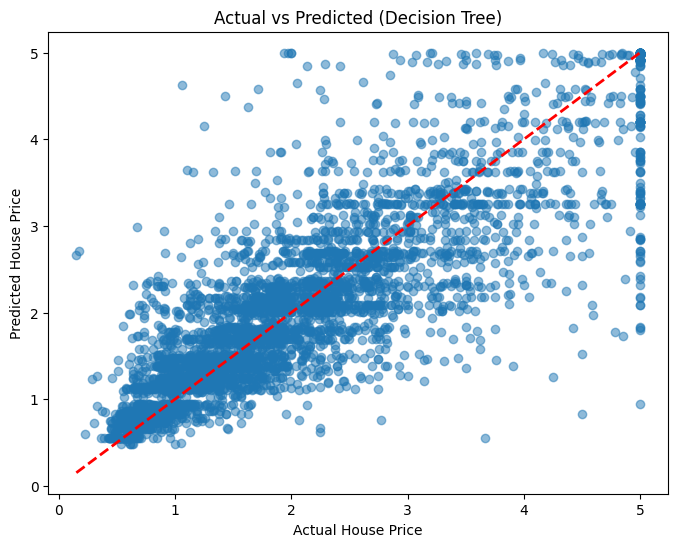

In [10]:
# Select the best model based on R² Score
best_model_name = results.iloc[0]["Model"]

if best_model_name == "Linear Regression":
    best_predictions = linear_predictions
elif best_model_name == "Ridge Regression":
    best_predictions = ridge_predictions
else:
    best_predictions = tree_predictions

plt.figure(figsize=(8,6))

plt.scatter(y_test, best_predictions, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(f"Actual vs Predicted ({best_model_name})")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.show()

# 💾 Step 11: Save the Best Model

The best-performing machine learning model is saved using Joblib.

The saved model can later be loaded to predict house prices without retraining.

In [11]:
import joblib

if best_model_name == "Linear Regression":
    joblib.dump(linear_model, "best_house_price_model.pkl")

elif best_model_name == "Ridge Regression":
    joblib.dump(ridge_model, "best_house_price_model.pkl")

else:
    joblib.dump(tree_model, "best_house_price_model.pkl")

print(f"✅ {best_model_name} saved as best_house_price_model.pkl")

✅ Decision Tree saved as best_house_price_model.pkl


# ✅ Conclusion

In this project, Feature Engineering techniques were applied using StandardScaler, and three regression algorithms were trained and evaluated.

The models were compared using MAE, RMSE, and R² Score to identify the best-performing model.

The selected model was saved for future use, demonstrating a complete machine learning workflow from preprocessing to model evaluation and deployment.